# ds005170 (Chisco) dataset audit

This notebook inspects the raw BIDS structure, EDF annotations, and Chinese text-label spreadsheets. It does **not** preprocess, alter, or download data.

In [1]:
from pathlib import Path
from collections import Counter
import json
import re
import zipfile
import xml.etree.ElementTree as ET
import pandas as pd
from IPython.display import display

def locate_dataset(start: Path) -> Path:
    for parent in (start, *start.parents):
        candidate = parent / 'data' / 'ds005170'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not locate data/ds005170. Open this notebook inside eeg_to_voice_chinese.')

DATASET = locate_dataset(Path.cwd().resolve())
description = json.loads((DATASET / 'dataset_description.json').read_text())
print(f'DATASET = {DATASET}')
print(description['Name'])

DATASET = /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/eeg2wave_server_bundle/eeg_to_voice_chinese/data/ds005170
Chisco


## 1. BIDS inventory

The raw recordings are continuous EDF files. They have EDF annotations but no BIDS `events.tsv`; text labels live in `textdataset/`.

In [2]:
edf_files = sorted(DATASET.glob('sub-*/ses-*/eeg/*_eeg.edf'))
text_files = sorted(
    (DATASET / 'textdataset').glob('split_data_*.xlsx'),
    key=lambda p: int(re.search(r'(\d+)$', p.stem).group(1)),
)
subjects = sorted({path.parts[-4] for path in edf_files})
sessions = sorted({path.parts[-3] for path in edf_files})

display(pd.Series({
    'subjects': len(subjects),
    'raw EDF recordings': len(edf_files),
    'runs per subject': len(edf_files) // len(subjects),
    'text-label spreadsheets': len(text_files),
    'BIDS events.tsv files': len(list(DATASET.glob('sub-*/ses-*/eeg/*_events.tsv'))),
    'audio WAV files': len(list(DATASET.rglob('*.wav'))),
}).to_frame('count'))

run_inventory = []
for path in edf_files:
    match = re.search(r'(sub-\d+)/(ses-\d+)/eeg/.*run-(\d+)_eeg\.edf$', path.as_posix())
    run_inventory.append({'subject': match.group(1), 'session': match.group(2), 'run': int(match.group(3))})
run_inventory = pd.DataFrame(run_inventory)
display(run_inventory.groupby(['subject', 'session']).size().rename('n_runs').unstack(fill_value=0))

,count
subjects,3
raw EDF recordings,135
runs per subject,45
text-label spreadsheets,45
BIDS events.tsv files,0
audio WAV files,0


session,ses-01,ses-02,ses-03,ses-04,ses-05
subject,,,,,
sub-01,7,8,10,10,10
sub-02,7,9,9,9,11
sub-03,7,9,10,10,9


## 2. Read the spreadsheet labels without external Excel packages

The helper below reads `xlsx` directly from its XML container, so it works even when `openpyxl` is not installed. Each row represents one prompted Chinese sentence and its semantic label.

In [3]:
XLSX_NS = {'x': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

def read_two_column_xlsx(path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(path) as archive:
        xml = archive.read('xl/worksheets/sheet1.xml')
    sheet = ET.fromstring(xml)
    rows = []
    for row in sheet.findall('.//x:sheetData/x:row', XLSX_NS):
        values = {}
        for cell in row.findall('x:c', XLSX_NS):
            column = re.match(r'[A-Z]+', cell.attrib['r']).group()
            values[column] = ''.join(node.text or '' for node in cell.findall('.//x:t', XLSX_NS))
        rows.append(values)
    header = rows[0]
    return pd.DataFrame([{
        header.get('A', 'sentence'): row.get('A', ''),
        header.get('B', 'label'): row.get('B', ''),
    } for row in rows[1:]])

label_frames = []
for path in text_files:
    frame = read_two_column_xlsx(path)
    frame['run'] = int(re.search(r'(\d+)$', path.stem).group(1))
    frame['source_file'] = path.name
    label_frames.append(frame)

labels = pd.concat(label_frames, ignore_index=True).rename(columns={'句子': 'sentence', '标签': 'semantic_label'})
display(labels.head())
display(labels.groupby('run').size().rename('n_prompted_sentences').to_frame().T)

,sentence,semantic_label,run,source_file
0,附近还有其他的酒店吗,预订和旅行安排,1,split_data_1.xlsx
1,我们只有没有淋浴的房间,住房和设施,1,split_data_1.xlsx
2,来这里，我能看到高大的樟树,自然和天气,1,split_data_1.xlsx
3,这是很棒的植物园,自然和天气,1,split_data_1.xlsx
4,听听大自然的声音,自然和天气,1,split_data_1.xlsx


run,1,2,3,4,5,6,7,8,9,10,...,36,37,38,39,40,41,42,43,44,45
n_prompted_sentences,200,150,150,150,150,150,150,150,150,150,...,150,150,150,150,150,150,150,150,150,31


## 3. Trial and label counts

The spreadsheet schedule has 45 runs. Every subject has the same run numbers `1…45`, so the primary audit estimate is the schedule total multiplied by three subjects. The EDF-header cell below validates representative run-level annotation counts.

In [4]:
n_schedule_trials = len(labels)
n_unique_sentences = labels['sentence'].nunique()
n_semantic_labels = labels['semantic_label'].nunique()
n_subjects = len(subjects)

display(pd.Series({
    'text schedule rows / trials per subject': n_schedule_trials,
    'estimated EEG trials across all subjects': n_schedule_trials * n_subjects,
    'unique sentence strings': n_unique_sentences,
    'semantic labels': n_semantic_labels,
    'raw runs per subject': len(run_inventory) // n_subjects,
}).to_frame('count'))

display(labels['semantic_label'].value_counts().rename_axis('semantic_label').to_frame('n_schedule_trials'))

,count
text schedule rows / trials per subject,6681
estimated EEG trials across all subjects,20043
unique sentence strings,6567
semantic labels,39
raw runs per subject,45


,n_schedule_trials
semantic_label,
求职和职业发展,323
饮食和用餐,309
情感和人际关系,271
个人行为和日常活动,271
健康和安全建议,270
询问和个人事务,265
工作和职场交流,260
教育和学习,228
交通和出行,222


## 4. Cross-check text categories against the supplied JSON mapping

In [5]:
text_to_class = json.loads((DATASET / 'json' / 'textmaps.json').read_text())
class_to_name = json.loads((DATASET / 'json' / 'classnumber.json').read_text())

mapped_codes = labels['sentence'].map(text_to_class)
print('Rows with a textmaps.json code:', mapped_codes.notna().sum(), '/', len(labels))
print('Text labels represented in classnumber.json:', labels.semantic_label.isin(class_to_name.values()).sum(), '/', len(labels))
display(pd.DataFrame({
    'class_code': [int(code) for code in sorted(class_to_name, key=int)],
    'semantic_label': [class_to_name[code] for code in sorted(class_to_name, key=int)],
}))

Rows with a textmaps.json code: 6681 / 6681
Text labels represented in classnumber.json: 6681 / 6681


,class_code,semantic_label
0,0,自然和天气
1,1,家庭关系和家庭事件
2,2,健康和安全建议
3,3,语言和学习
4,4,金融和付款
5,5,个人信息
6,6,提供和请求帮助
7,7,问候和情感状态
8,8,表演艺术
9,9,人际交往和情感表达


## 5. Optional: inspect EDF headers and annotation counts

This reads only EDF headers (`preload=False`), never the full signal. It checks run 1, a typical 150-sentence run, and the final short run.

In [7]:
import mne

def edf_path(subject: str, run: int) -> Path:
    # Run numbering is not consistently zero-padded (e.g. run-1 and run-045).
    candidates = sorted(DATASET.glob(f'{subject}/ses-*/eeg/*_eeg.edf'))
    matches = [path for path in candidates if re.search(r'run-(\d+)_eeg\.edf$', path.name) and int(re.search(r'run-(\d+)_eeg\.edf$', path.name).group(1)) == run]
    if len(matches) != 1:
        raise RuntimeError(f'Expected one EDF for {subject} run {run}; found {len(matches)}: {matches}')
    return matches[0]

header_rows = []
for run in (1, 2, 45):
    path = edf_path('sub-01', run)
    raw = mne.io.read_raw_edf(path, preload=False, verbose='ERROR')
    header_rows.append({
        'run': run,
        'label_rows': int((labels['run'] == run).sum()),
        'EDF_annotations': len(raw.annotations),
        'sampling_hz': raw.info['sfreq'],
        'channels': len(raw.ch_names),
        'duration_s': round(raw.times[-1], 3),
        'annotation_descriptions': sorted(set(raw.annotations.description)),
    })
display(pd.DataFrame(header_rows))

,run,label_rows,EDF_annotations,sampling_hz,channels,duration_s,annotation_descriptions
0,1,200,200,1000.0,133,2221.999,[100]
1,2,150,150,1000.0,133,1818.399,[100]
2,45,31,31,1000.0,133,513.999,[100]


## 6. Full annotation-count audit (optional)

Set `RUN_FULL_HEADER_AUDIT = True` only when you want to scan annotations in every EDF. It may take several minutes but does not load full EEG arrays.

In [8]:
RUN_FULL_HEADER_AUDIT = False

if RUN_FULL_HEADER_AUDIT:
    rows = []
    for path in edf_files:
        match = re.search(r'(sub-\d+)/(ses-\d+)/eeg/.*run-(\d+)_eeg\.edf$', path.as_posix())
        raw = mne.io.read_raw_edf(path, preload=False, verbose='ERROR')
        rows.append({
            'subject': match.group(1), 'session': match.group(2), 'run': int(match.group(3)),
            'annotations': len(raw.annotations),
        })
    annotation_audit = pd.DataFrame(rows)
    display(annotation_audit.groupby('subject').annotations.agg(['count', 'sum', 'min', 'max']))
    expected = labels.groupby('run').size().rename('expected_annotations')
    checked = annotation_audit.join(expected, on='run')
    print('Run-level annotation / text-schedule agreement:', (checked.annotations == checked.expected_annotations).mean())
else:
    print('Skipped. Change RUN_FULL_HEADER_AUDIT to True to validate every EDF header.')

Skipped. Change RUN_FULL_HEADER_AUDIT to True to validate every EDF header.


## Interpretation before EEG-to-voice modelling

- This is an imagined-speech EEG + Chinese text/semantic-label dataset; no paired WAV recordings are supplied.
- The reconstruction target can therefore be text/content or a separately generated canonical TTS signal, not the participant's original trial-specific voice.
- Build the EEG→sentence/semantic-content manifest only after confirming that EDF annotation order and `split_data_<run>.xlsx` order agree for every run.
- Keep subject-level splits: the same 45 text schedules appear to be reused across the three subjects, so random trial splitting can overestimate cross-subject generalization.

## 7. EEG visualization (read-only)

This loads only a short window around the first EDF annotation. It produces a waveform view, power spectral density (PSD), and annotation timeline; it does not filter or save data.

Reading 0 ... 200000  =      0.000 ...   200.000 secs...
sub-01/ses-01/eeg/sub-01_ses-01_task-imagine_run-01_eeg.edf | 1000.0 Hz | 133 channels | 88.53–288.53 s


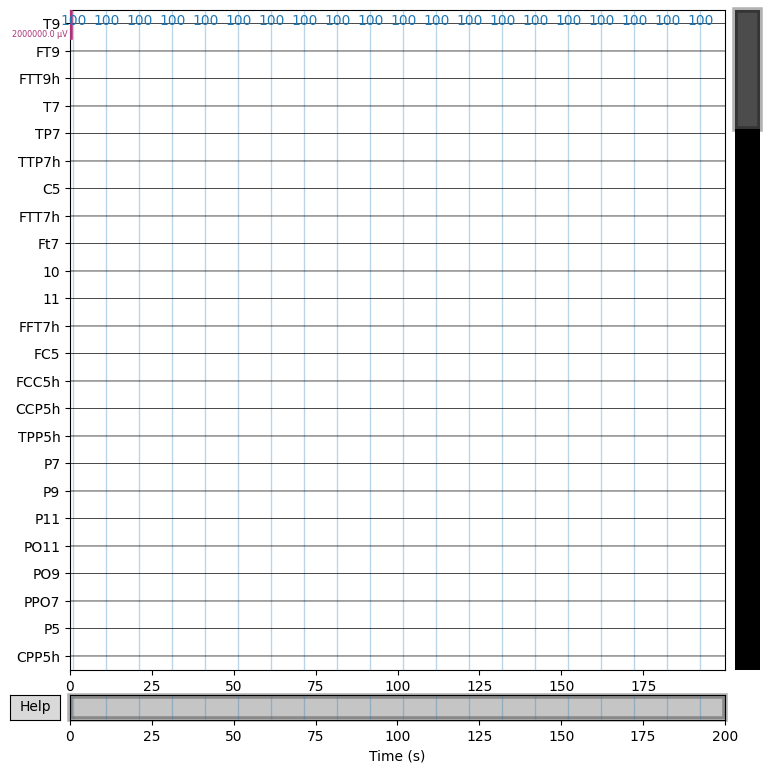

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/eegvoice/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


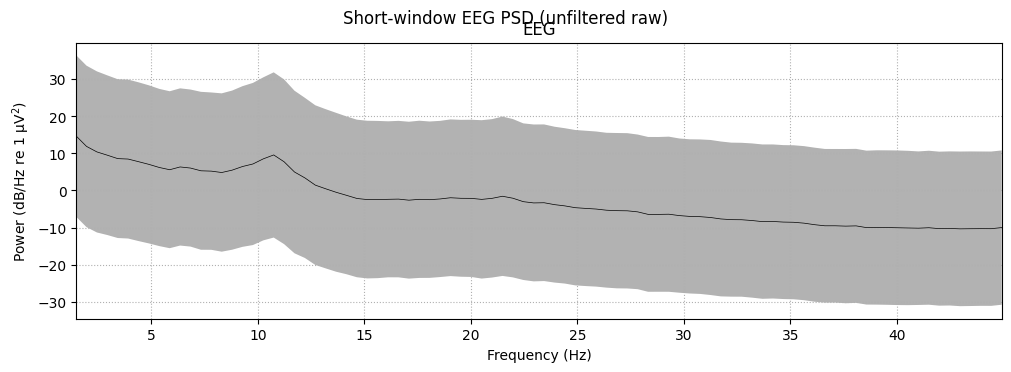

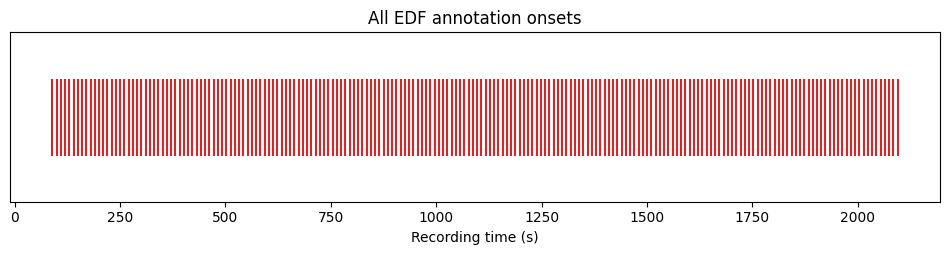

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import mne

PLOT_SUBJECT = 'sub-01'
PLOT_RUN = 1
PLOT_SECONDS = 200.0

plot_path = edf_path(PLOT_SUBJECT, PLOT_RUN)
raw_plot = mne.io.read_raw_edf(plot_path, preload=False, verbose='ERROR')
first_onset = float(raw_plot.annotations.onset[0]) if len(raw_plot.annotations) else 0.0
tmin = max(0.0, first_onset - 1.0)
tmax = min(tmin + PLOT_SECONDS, raw_plot.times[-1])
window = raw_plot.copy().crop(tmin=tmin, tmax=tmax).load_data()

print(f'{plot_path.relative_to(DATASET)} | {window.info["sfreq"]} Hz | {len(window.ch_names)} channels | {tmin:.2f}–{tmax:.2f} s')
window.plot(duration=min(PLOT_SECONDS, tmax - tmin), n_channels=min(24, len(window.ch_names)), scalings='auto', show_scrollbars=True)

fig_psd = window.compute_psd(fmin=1, fmax=45).plot(average=True, spatial_colors=False)
fig_psd.suptitle('Short-window EEG PSD (unfiltered raw)', y=1.02)

fig, ax = plt.subplots(figsize=(12, 2.2))
ax.eventplot(raw_plot.annotations.onset, colors='tab:red', lineoffsets=0, linelengths=0.8)
ax.set(xlabel='Recording time (s)', yticks=[], title='All EDF annotation onsets')
plt.show()

## 8. Audio listener

Chisco does not supply recorded WAV/FLAC files. This cell searches the dataset and `eeg_output/audio_16k/`; it will play the first real WAV/FLAC only after you add a separately generated canonical-TTS or model-output file.

In [13]:
from IPython.display import Audio, display

audio_roots = [DATASET, DATASET.parent.parent / 'eeg_output' / 'audio_16k']
audio_files = sorted({path for root in audio_roots if root.exists() for ext in ('*.wav', '*.flac') for path in root.rglob(ext)})
if audio_files:
    selected_audio = audio_files[0]
    print('Playing:', selected_audio)
    display(Audio(filename=str(selected_audio)))
else:
    print('No WAV/FLAC found. Chisco contains no trial-recorded audio; add only clearly labelled canonical-TTS or model-output WAVs to eeg_output/audio_16k/.')

No WAV/FLAC found. Chisco contains no trial-recorded audio; add only clearly labelled canonical-TTS or model-output WAVs to eeg_output/audio_16k/.
